In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, re, math, json, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

from wordcloud import WordCloud

nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

PALETTE = ["#4361EE","#3A0CA3","#7209B7","#F72585","#4CC9F0",
           "#06D6A0","#FFB703","#FB8500","#E63946","#2EC4B6"]

DATA_PATH = "mtsamples.csv"   # <-- adjust if needed
print("✅ Libraries loaded")

✅ Libraries loaded


📋 Total reports      : 4,966
🏷️  Unique specialties : 40
📝 Avg. tokens/report : 465


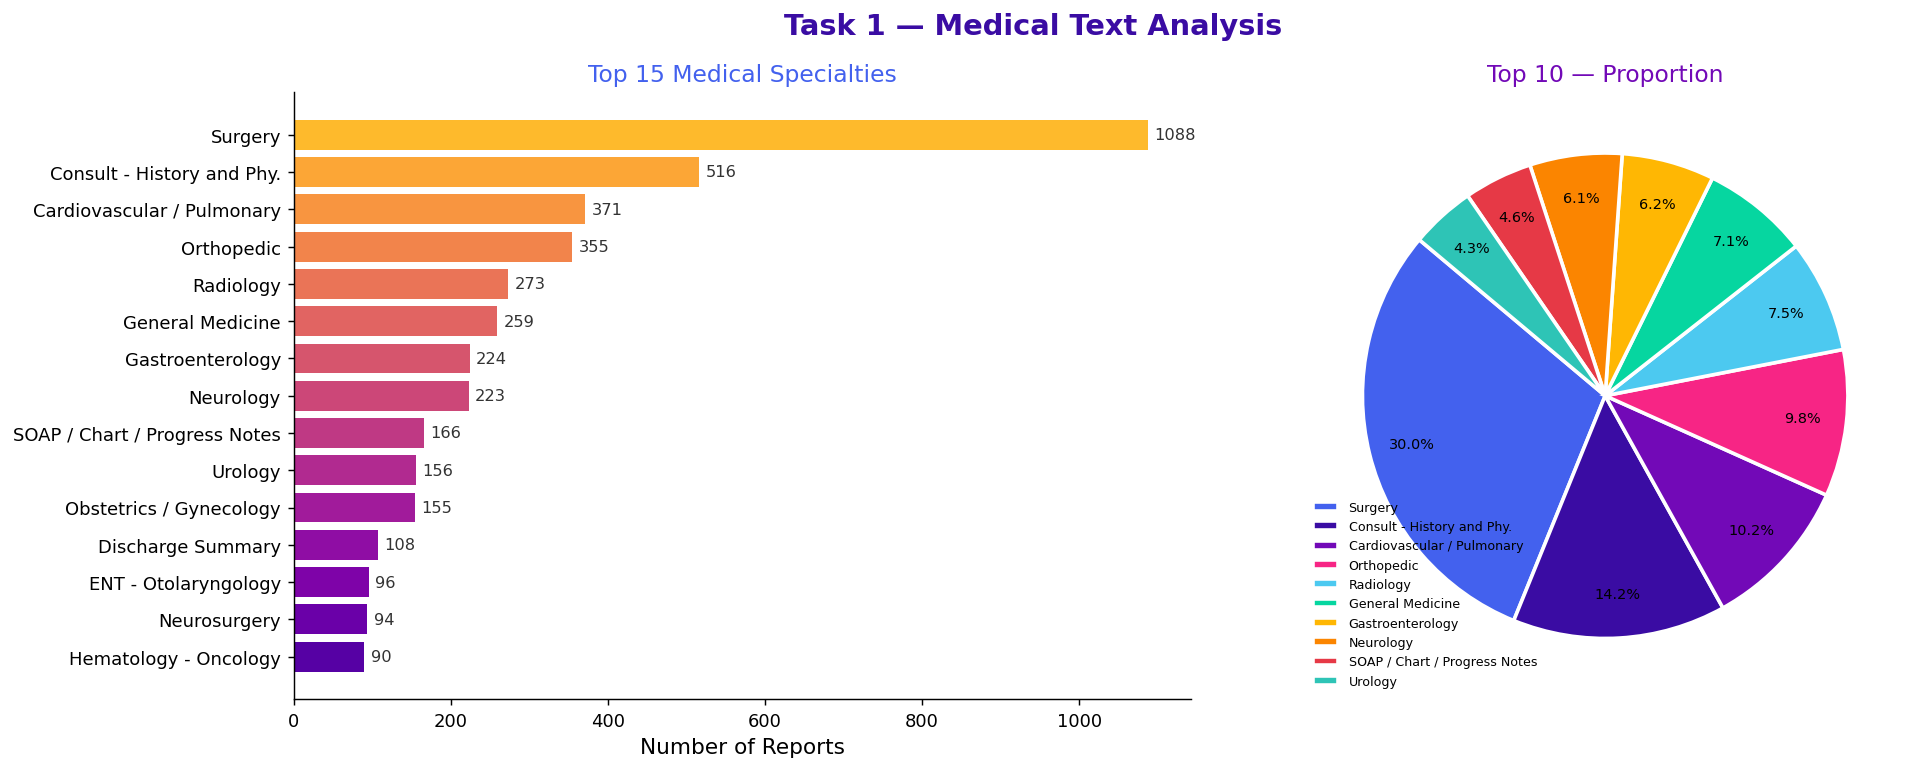

✅ Task 1 chart saved


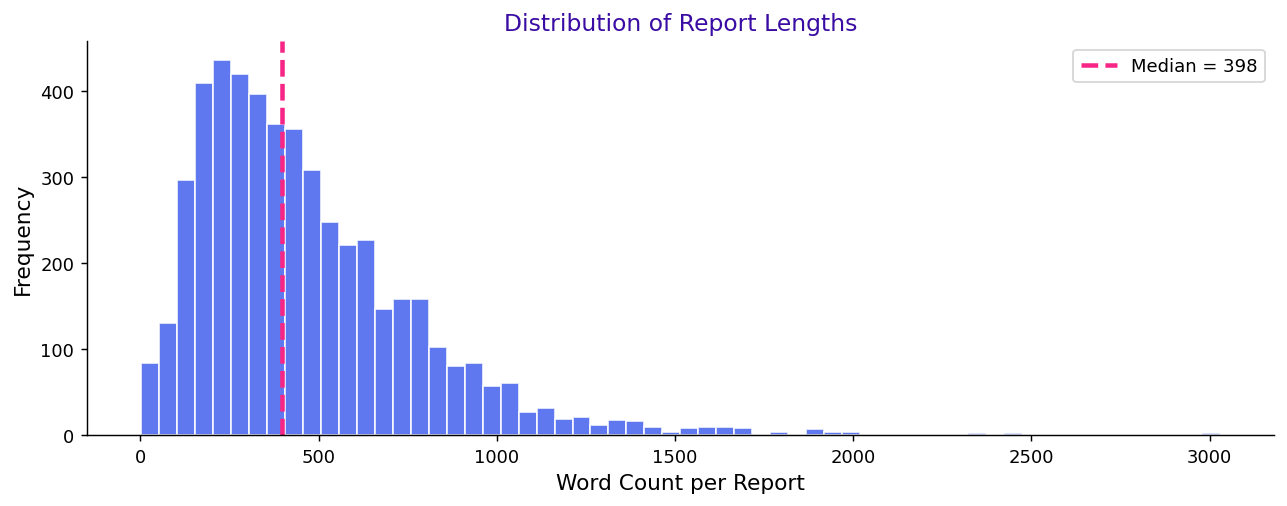


🔬 Top 30 Medical Terms:
   1. blood                     3,956
   2. skin                      3,798
   3. anesthesia                3,707
   4. incision                  3,601
   5. removed                   3,532
   6. year                      3,504
   7. room                      3,502
   8. diagnosis                 3,212
   9. general                   3,064
  10. artery                    3,027
  11. anterior                  2,932
  12. back                      2,731
  13. disease                   2,685
  14. past                      2,674
  15. chest                     2,631
  16. examination               2,578
  17. position                  2,576
  18. lower                     2,462
  19. fashion                   2,445
  20. neck                      2,424
  21. negative                  2,374
  22. present                   2,368
  23. made                      2,352
  24. upper                     2,324
  25. pressure                  2,284
  26. closed             

In [2]:
# ─────────────────────────────────────────────
# CELL 1 ▸ TASK 1 — Medical Text Analysis
# ─────────────────────────────────────────────
 
# ---------- Load & clean ----------
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)
 
df["medical_specialty"] = df["medical_specialty"].str.strip()
df.dropna(subset=["transcription"], inplace=True)
df.reset_index(drop=True, inplace=True)
 
print(f"📋 Total reports      : {len(df):,}")
print(f"🏷️  Unique specialties : {df['medical_specialty'].nunique()}")
print(f"📝 Avg. tokens/report : {df['transcription'].apply(lambda x: len(x.split())).mean():.0f}")
 
# ---------- Specialty distribution bar ----------
spec_counts = df["medical_specialty"].value_counts().head(15)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Task 1 — Medical Text Analysis", fontsize=16, fontweight="bold", color="#3A0CA3")
 
# Bar chart
bars = axes[0].barh(spec_counts.index[::-1], spec_counts.values[::-1],
                    color=plt.cm.plasma(np.linspace(0.15, 0.85, 15)))
axes[0].set_xlabel("Number of Reports", fontsize=12)
axes[0].set_title("Top 15 Medical Specialties", fontsize=13, color="#4361EE")
for bar, val in zip(bars, spec_counts.values[::-1]):
    axes[0].text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
                 str(val), va="center", fontsize=9, color="#333")
 
# Donut chart (top 10)
top10 = spec_counts.head(10)
wedges, texts, autotexts = axes[1].pie(
    top10.values, labels=None,
    autopct="%1.1f%%", startangle=140,
    colors=PALETTE, pctdistance=0.82,
    wedgeprops={"linewidth": 2, "edgecolor": "white"})
axes[1].set_title("Top 10 — Proportion", fontsize=13, color="#7209B7")
axes[1].legend(wedges, top10.index, loc="lower left", fontsize=7, frameon=False)
for at in autotexts:
    at.set_fontsize(8)
 
plt.tight_layout()
plt.savefig("task1_distribution.png", bbox_inches="tight")
plt.show()
print("✅ Task 1 chart saved")
 
# ---------- Report length distribution ----------
df["word_count"] = df["transcription"].apply(lambda x: len(x.split()))
fig2, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["word_count"], bins=60, color="#4361EE", edgecolor="white", alpha=0.85)
ax.axvline(df["word_count"].median(), color="#F72585", lw=2.5, linestyle="--",
           label=f'Median = {df["word_count"].median():.0f}')
ax.set_xlabel("Word Count per Report", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Distribution of Report Lengths", fontsize=13, color="#3A0CA3")
ax.legend()
plt.tight_layout()
plt.savefig("task1_lengths.png", bbox_inches="tight")
plt.show()
 
# ---------- Most common medical terms ----------
MEDICAL_STOP = set(stopwords.words("english")) | {
    "patient","procedure","history","right","left","normal","noted",
    "well","also","would","placed","used","pain","performed","using",
    "without","within","noted","taken","given","showed","including",
    "however","upon","following","area","good","time","day","days",
    "one","two","three","four","five","able","findings"}
 
all_text = " ".join(df["transcription"].fillna("").tolist()).lower()
tokens = re.findall(r"\b[a-z]{4,}\b", all_text)
tokens = [t for t in tokens if t not in MEDICAL_STOP]
term_freq = Counter(tokens)
top_terms = term_freq.most_common(30)
 
print("\n🔬 Top 30 Medical Terms:")
for i, (term, freq) in enumerate(top_terms, 1):
    print(f"  {i:>2}. {term:<25} {freq:,}")
 

📚 Vocabulary size     : 19,621 unique terms
🏆 Most frequent term  : 'blood' (3,956x)


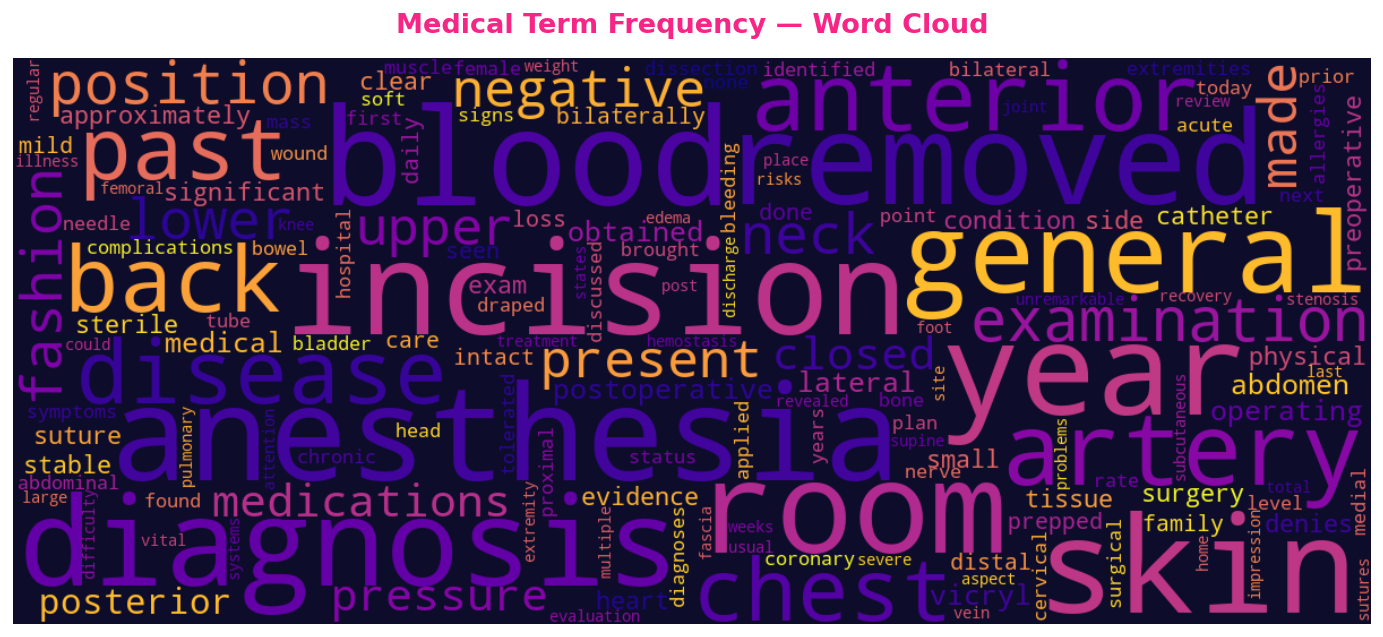

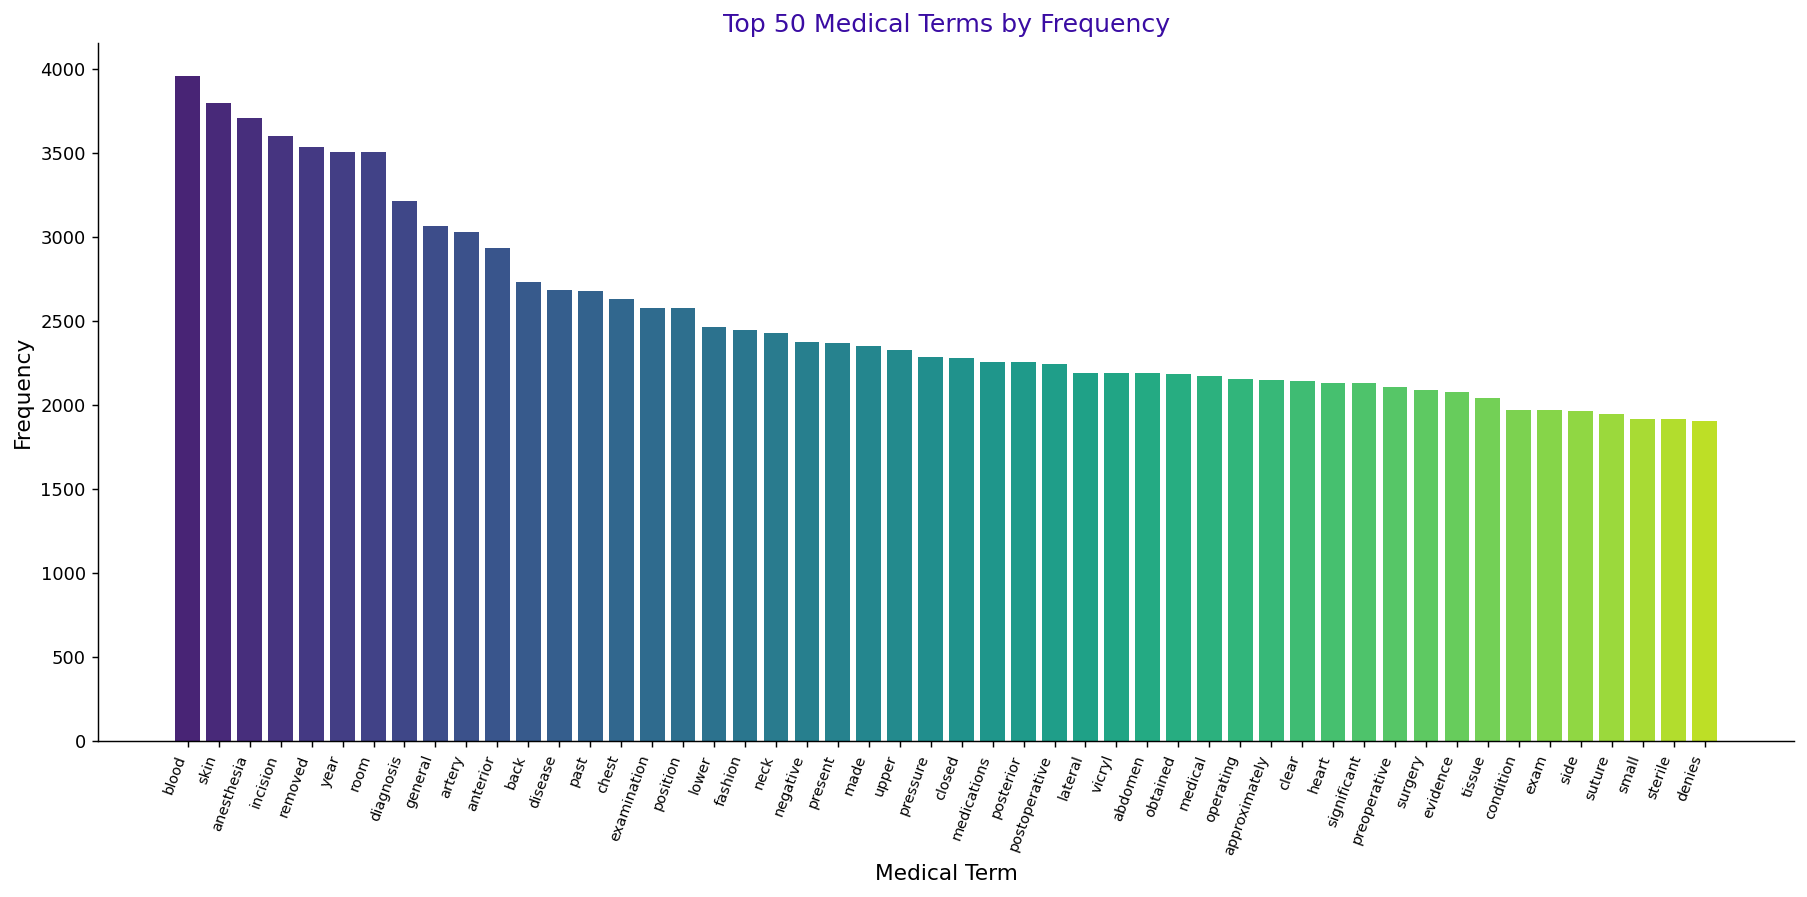

✅ Task 2 complete — medical_vocabulary.csv saved


In [3]:
# ─────────────────────────────────────────────
# CELL 2 ▸ TASK 2 — Medical Vocabulary Builder
# ─────────────────────────────────────────────

# Full vocabulary with frequency
vocab_df = pd.DataFrame(term_freq.most_common(), columns=["term", "frequency"])
vocab_df["rank"] = range(1, len(vocab_df)+1)
vocab_df.to_csv("medical_vocabulary.csv", index=False)

print(f"📚 Vocabulary size     : {len(vocab_df):,} unique terms")
print(f"🏆 Most frequent term  : '{vocab_df.iloc[0]['term']}' ({vocab_df.iloc[0]['frequency']:,}x)")

# ── WordCloud ──
wc_data = {t: f for t, f in term_freq.most_common(300)}
wc = WordCloud(width=1200, height=500, background_color="#0D0D2B",
               colormap="plasma", max_font_size=120, min_font_size=12,
               collocations=False).generate_from_frequencies(wc_data)

fig3, ax = plt.subplots(figsize=(14, 5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Medical Term Frequency — Word Cloud", fontsize=15,
             color="#F72585", fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig("task2_wordcloud.png", bbox_inches="tight")
plt.show()

# ── Top-50 frequency bar ──
top50 = vocab_df.head(50)
fig4, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(top50["term"], top50["frequency"],
              color=plt.cm.viridis(np.linspace(0.1, 0.9, 50)))
ax.set_xlabel("Medical Term", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Top 50 Medical Terms by Frequency", fontsize=14, color="#3A0CA3")
ax.set_xticklabels(top50["term"], rotation=70, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("task2_top50.png", bbox_inches="tight")
plt.show()
print("✅ Task 2 complete — medical_vocabulary.csv saved")

In [4]:
# ─────────────────────────────────────────────
# CELL 3 ▸ Data Preprocessing (shared for Tasks 3-6)
# ─────────────────────────────────────────────

# Focus on top 10 specialties for classification
TOP_N = 10
top_specs = df["medical_specialty"].value_counts().head(TOP_N).index.tolist()
df_cls = df[df["medical_specialty"].isin(top_specs)].copy()
df_cls.reset_index(drop=True, inplace=True)

le = LabelEncoder()
df_cls["label"] = le.fit_transform(df_cls["medical_specialty"])
NUM_CLASSES = len(le.classes_)
print(f"🎯 Classes: {NUM_CLASSES} | Samples: {len(df_cls):,}")

# ── Build vocabulary from tokens ──
MAX_LEN = 200
VOCAB_SIZE = 10000

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if len(t) > 2 and t not in MEDICAL_STOP]
    return tokens

df_cls["tokens"] = df_cls["transcription"].apply(clean_text)

# Build vocab
all_tokens = [t for tokens in df_cls["tokens"] for t in tokens]
token_freq = Counter(all_tokens)
vocab = ["<PAD>", "<UNK>"] + [t for t, _ in token_freq.most_common(VOCAB_SIZE - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}

def encode(tokens, max_len=MAX_LEN):
    ids = [word2idx.get(t, 1) for t in tokens[:max_len]]
    ids += [0] * (max_len - len(ids))
    return ids

df_cls["input_ids"] = df_cls["tokens"].apply(encode)

X = np.array(df_cls["input_ids"].tolist())
y = np.array(df_cls["label"].tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── PyTorch Dataset ──
class MedDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = MedDataset(X_train, y_train)
test_ds  = MedDataset(X_test,  y_test)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=64)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Device: {DEVICE}")

🎯 Classes: 10 | Samples: 3,631
Train: 2904 | Test: 727
🖥️  Device: cpu


▶ Training Baseline Model …
  Epoch 1/8  Train Acc=0.354  Val Acc=0.450  Val Loss=1.7994
  Epoch 2/8  Train Acc=0.457  Val Acc=0.461  Val Loss=1.4820
  Epoch 3/8  Train Acc=0.485  Val Acc=0.450  Val Loss=1.3985
  Epoch 4/8  Train Acc=0.498  Val Acc=0.446  Val Loss=1.3764
  Epoch 5/8  Train Acc=0.516  Val Acc=0.428  Val Loss=1.3746
  Epoch 6/8  Train Acc=0.522  Val Acc=0.428  Val Loss=1.3580
  Epoch 7/8  Train Acc=0.532  Val Acc=0.431  Val Loss=1.3522
  Epoch 8/8  Train Acc=0.543  Val Acc=0.429  Val Loss=1.3472

✅ Baseline Test Accuracy: 0.4292
                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.38      0.31      0.34        74
   Consult - History and Phy.       0.42      0.64      0.50       103
             Gastroenterology       0.26      0.20      0.23        45
             General Medicine       0.37      0.29      0.32        52
                    Neurology       0.35      0.31      0.33        45
                   Orth

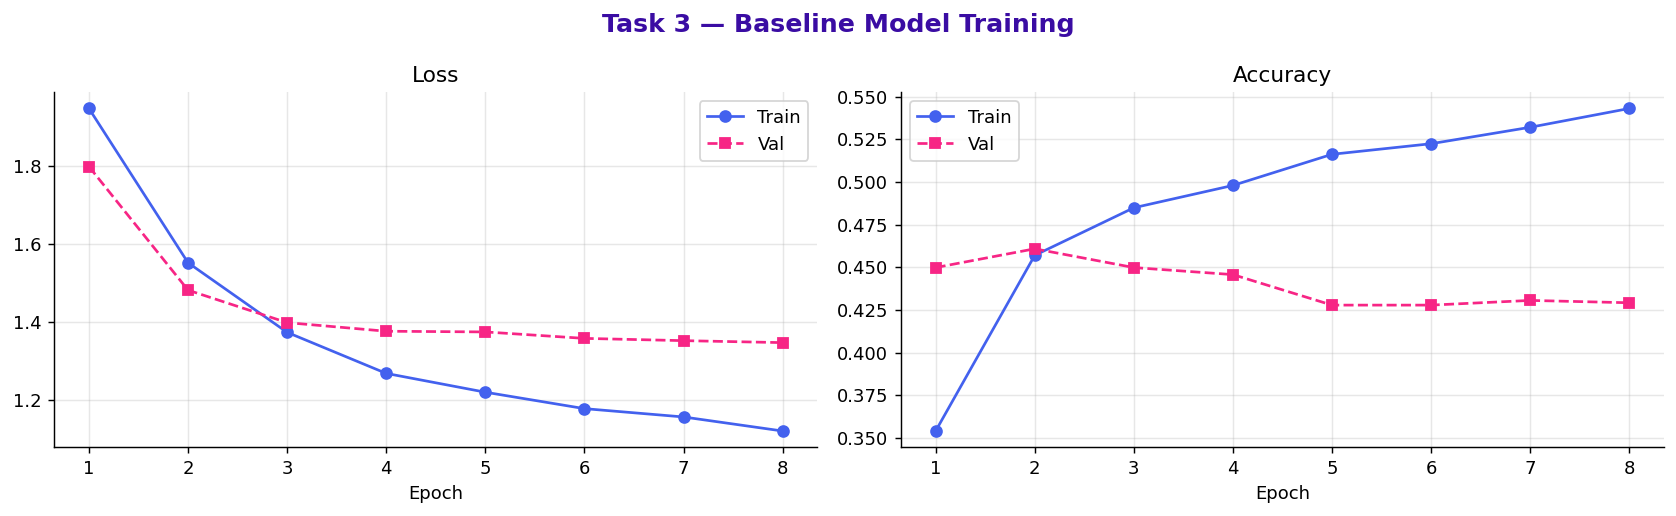

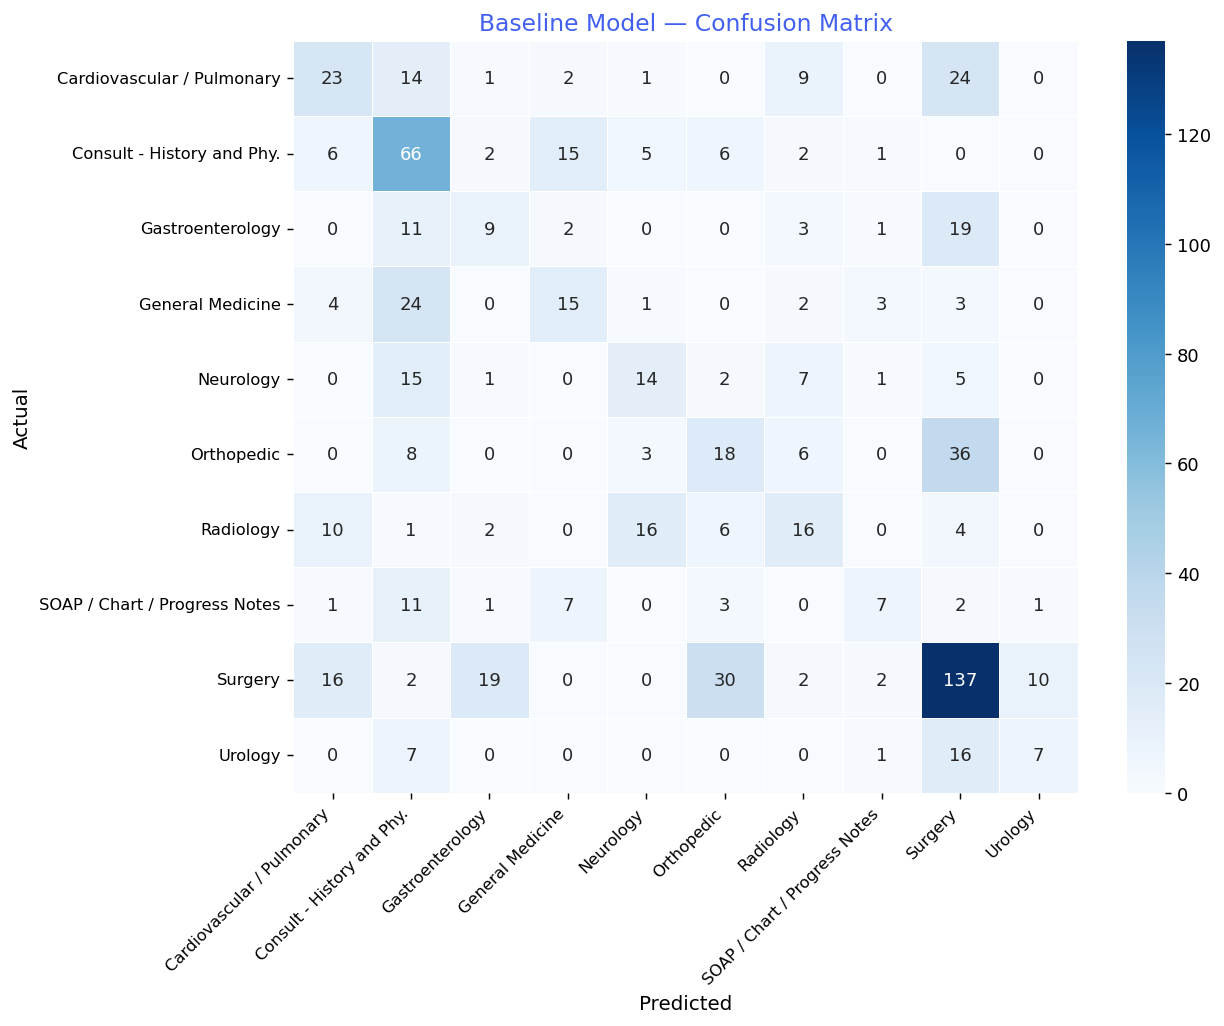

✅ Baseline model saved → baseline_model.pt


In [5]:
# ─────────────────────────────────────────────
# CELL 4 ▸ TASK 3 — Baseline Embedding → Dense Model
# ─────────────────────────────────────────────

class BaselineModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, num_classes)

    def forward(self, x):
        emb = self.embedding(x)          # (B, L, E)
        emb = emb.mean(dim=1)            # mean pooling → (B, E)
        emb = self.dropout(emb)
        h = F.relu(self.bn1(self.fc1(emb)))
        h = self.dropout(h)
        h = F.relu(self.fc2(h))
        return self.fc3(h)

def train_model(model, train_dl, test_dl, epochs=8, lr=1e-3):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=3, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        # --- train ---
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            opt.step()
            t_loss += loss.item() * len(yb)
            t_correct += (out.argmax(1) == yb).sum().item()
            t_total += len(yb)
        scheduler.step()

        # --- val ---
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in test_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                v_loss += criterion(out, yb).item() * len(yb)
                v_correct += (out.argmax(1) == yb).sum().item()
                v_total += len(yb)

        history["train_loss"].append(t_loss / t_total)
        history["train_acc"].append(t_correct / t_total)
        history["val_loss"].append(v_loss / v_total)
        history["val_acc"].append(v_correct / v_total)
        print(f"  Epoch {epoch+1}/{epochs}  "
              f"Train Acc={history['train_acc'][-1]:.3f}  "
              f"Val Acc={history['val_acc'][-1]:.3f}  "
              f"Val Loss={history['val_loss'][-1]:.4f}")

    return history

baseline = BaselineModel(VOCAB_SIZE, embed_dim=128, hidden_dim=256,
                         num_classes=NUM_CLASSES)
print("▶ Training Baseline Model …")
h_baseline = train_model(baseline, train_dl, test_dl, epochs=8)

# ── Evaluate ──
baseline.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        preds = baseline(xb.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

baseline_acc = accuracy_score(all_true, all_preds)
print(f"\n✅ Baseline Test Accuracy: {baseline_acc:.4f}")
print(classification_report(all_true, all_preds, target_names=le.classes_))

# ── Plots ──
def plot_history(h, title, color_train="#4361EE", color_val="#F72585"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=14, fontweight="bold", color="#3A0CA3")
    epochs = range(1, len(h["train_loss"])+1)

    axes[0].plot(epochs, h["train_loss"], "o-", color=color_train, label="Train")
    axes[0].plot(epochs, h["val_loss"],   "s--", color=color_val, label="Val")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, h["train_acc"], "o-", color=color_train, label="Train")
    axes[1].plot(epochs, h["val_acc"],   "s--", color=color_val, label="Val")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    return fig

fig_b = plot_history(h_baseline, "Task 3 — Baseline Model Training")
plt.savefig("task3_baseline_training.png", bbox_inches="tight")
plt.show()

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
fig_cm, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, ax=ax)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual", fontsize=11)
ax.set_title("Baseline Model — Confusion Matrix", fontsize=13, color="#4361EE")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("task3_confusion.png", bbox_inches="tight")
plt.show()

torch.save(baseline.state_dict(), "baseline_model.pt")
print("✅ Baseline model saved → baseline_model.pt")


▶ Training Attention Model …
  Epoch 1/8  Train Acc=0.387  Val Acc=0.451  Val Loss=1.7006
  Epoch 2/8  Train Acc=0.447  Val Acc=0.457  Val Loss=1.6263
  Epoch 3/8  Train Acc=0.465  Val Acc=0.470  Val Loss=1.5936
  Epoch 4/8  Train Acc=0.488  Val Acc=0.468  Val Loss=1.5556
  Epoch 5/8  Train Acc=0.483  Val Acc=0.464  Val Loss=1.5156
  Epoch 6/8  Train Acc=0.492  Val Acc=0.475  Val Loss=1.4900
  Epoch 7/8  Train Acc=0.501  Val Acc=0.477  Val Loss=1.4951
  Epoch 8/8  Train Acc=0.503  Val Acc=0.480  Val Loss=1.4846

✅ Attention Model Test Accuracy: 0.4801
                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary       0.38      0.22      0.28        74
   Consult - History and Phy.       0.40      0.82      0.54       103
             Gastroenterology       0.33      0.02      0.04        45
             General Medicine       0.47      0.13      0.21        52
                    Neurology       0.23      0.16      0.18        45
               

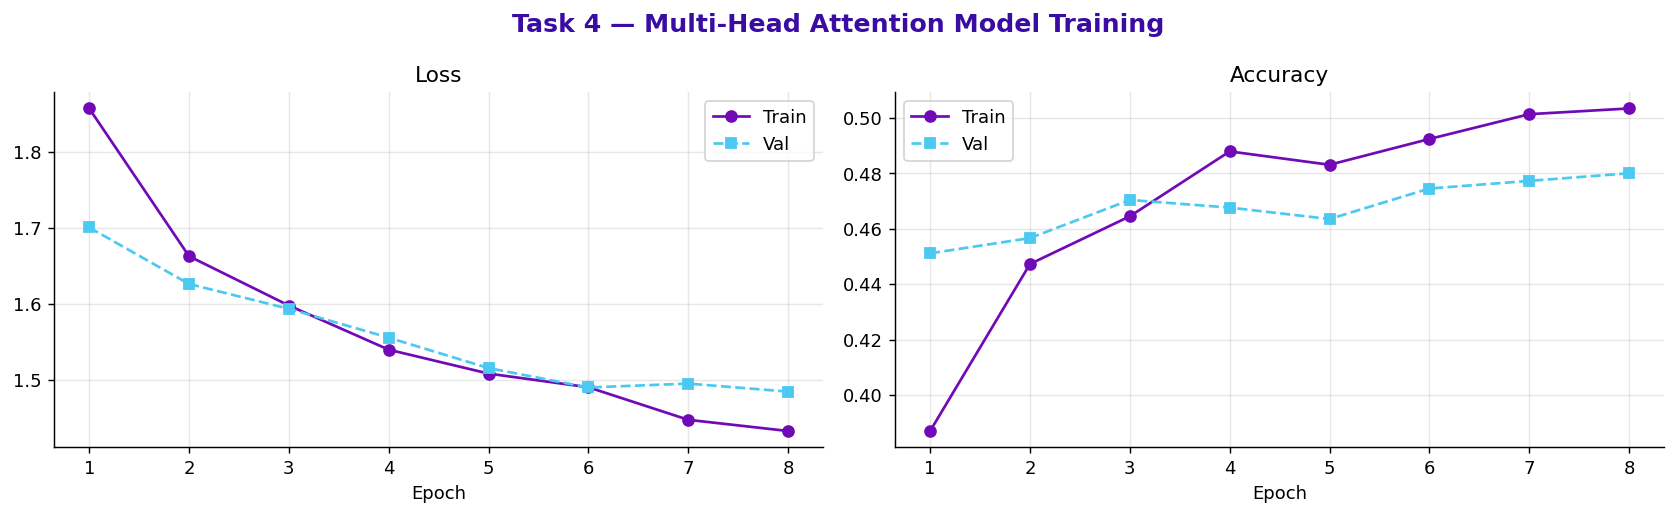

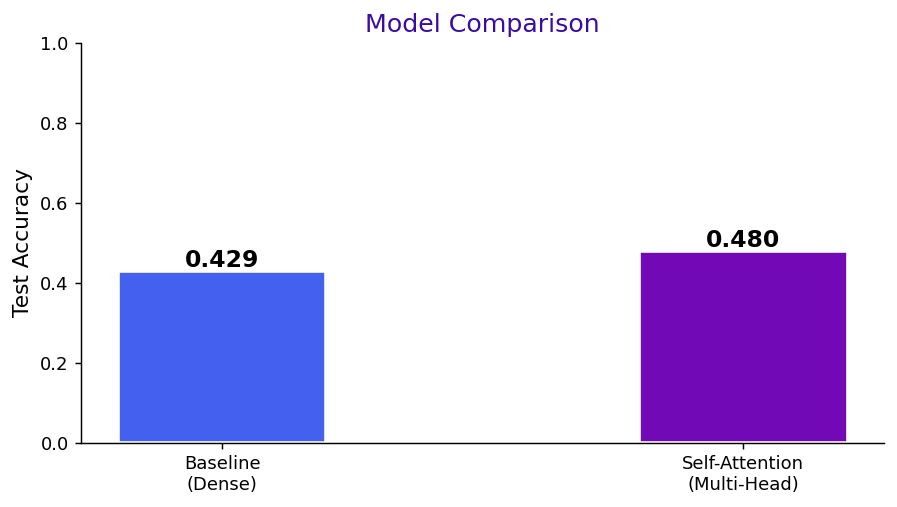

✅ Attention model saved → attn_model.pt


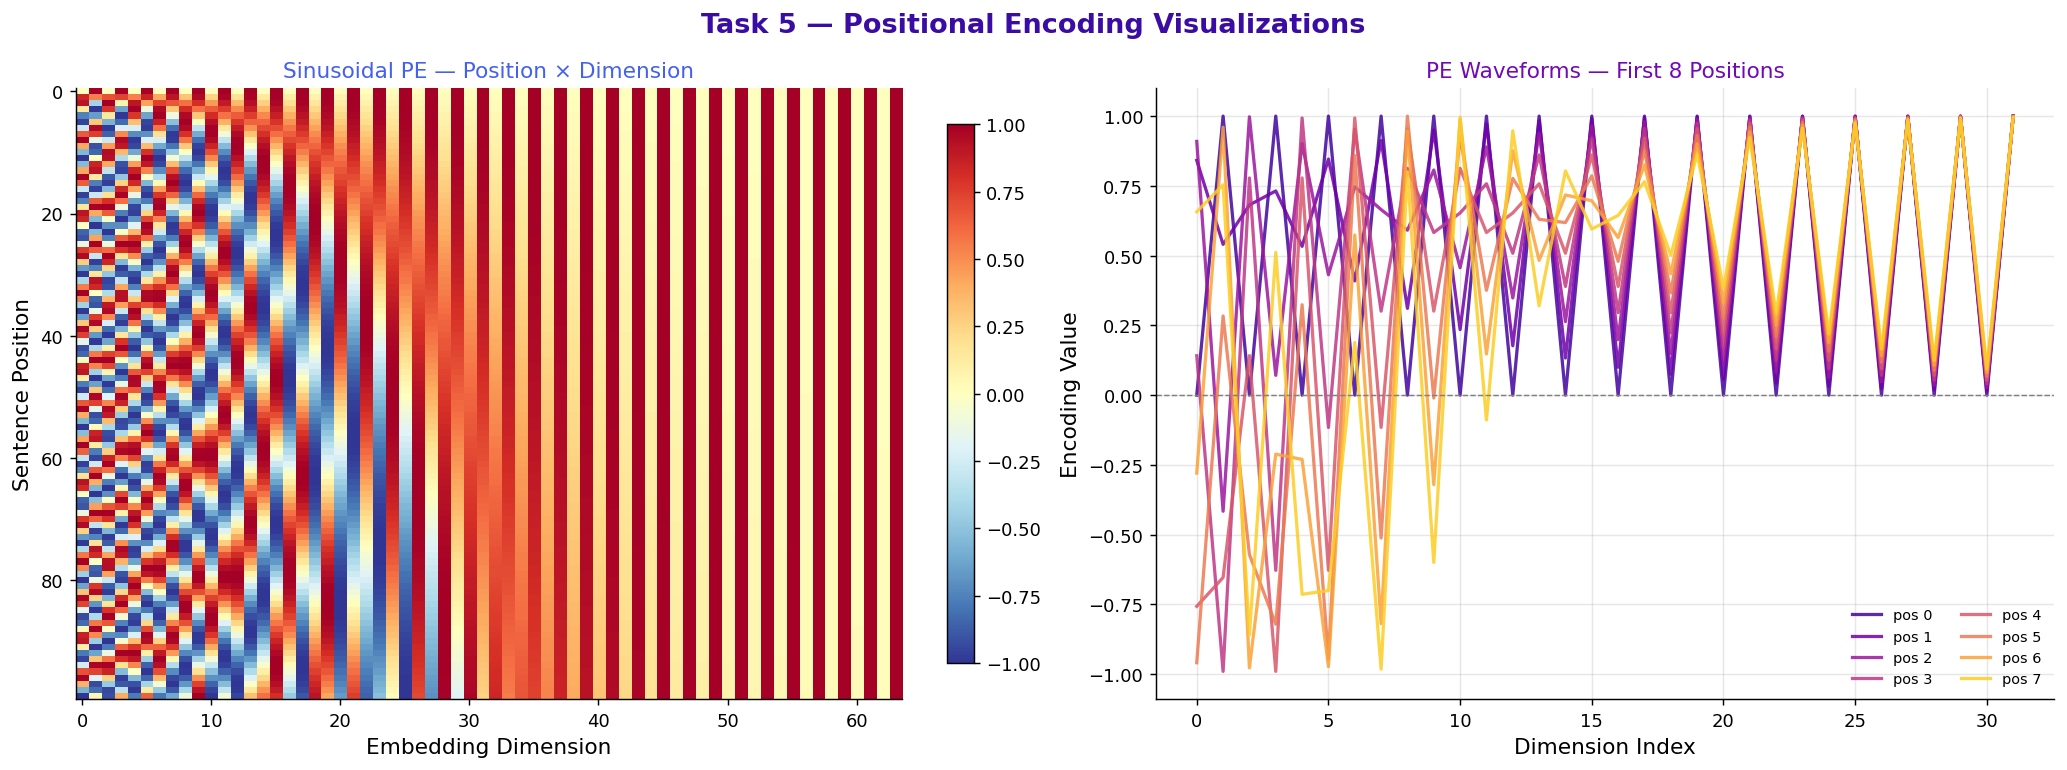

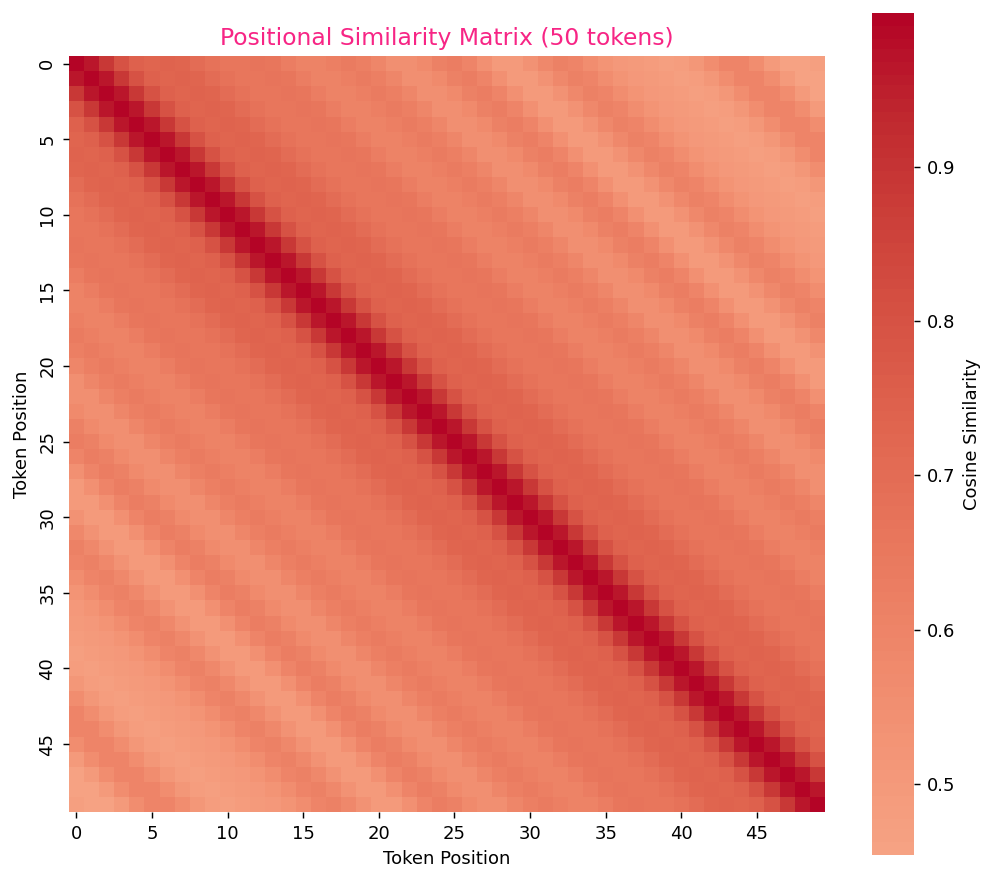

✅ Task 5 — Positional encoding visualised


In [6]:
# ─────────────────────────────────────────────
# CELL 5 ▸ TASK 4 — Self-Attention (Multi-Head) Model
# ─────────────────────────────────────────────

class MedicalAttentionModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, hidden_dim,
                 num_classes, dropout=0.3, max_len=MAX_LEN):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoding = nn.Embedding(max_len, embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads,
                                          dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ff    = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
        )
        self.norm2   = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x, return_attn=False):
        B, L = x.shape
        positions = torch.arange(L, device=x.device).unsqueeze(0).expand(B, -1)
        emb = self.embedding(x) + self.pos_encoding(positions)
        emb = self.dropout(emb)

        key_padding_mask = (x == 0)
        attn_out, attn_weights = self.attn(emb, emb, emb,
                                           key_padding_mask=key_padding_mask)
        emb = self.norm1(emb + attn_out)
        emb = self.norm2(emb + self.ff(emb))

        # CLS-style pooling: take [0] token
        pooled = emb[:, 0, :]
        if return_attn:
            return self.classifier(pooled), attn_weights
        return self.classifier(pooled)

attn_model = MedicalAttentionModel(
    VOCAB_SIZE, embed_dim=128, num_heads=4,
    hidden_dim=256, num_classes=NUM_CLASSES
)
print("▶ Training Attention Model …")
h_attn = train_model(attn_model, train_dl, test_dl, epochs=8)

# Evaluate
attn_model.eval()
a_preds, a_true = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        preds = attn_model(xb.to(DEVICE)).argmax(1).cpu().numpy()
        a_preds.extend(preds)
        a_true.extend(yb.numpy())

attn_acc = accuracy_score(a_true, a_preds)
print(f"\n✅ Attention Model Test Accuracy: {attn_acc:.4f}")
print(classification_report(a_true, a_preds, target_names=le.classes_))

fig_a = plot_history(h_attn, "Task 4 — Multi-Head Attention Model Training",
                     color_train="#7209B7", color_val="#4CC9F0")
plt.savefig("task4_attn_training.png", bbox_inches="tight")
plt.show()

# Model comparison bar
fig_cmp, ax = plt.subplots(figsize=(7, 4))
models  = ["Baseline\n(Dense)", "Self-Attention\n(Multi-Head)"]
accs    = [baseline_acc, attn_acc]
colors  = ["#4361EE", "#7209B7"]
bars    = ax.bar(models, accs, color=colors, width=0.4, edgecolor="white", linewidth=2)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Test Accuracy", fontsize=12)
ax.set_title("Model Comparison", fontsize=14, color="#3A0CA3")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{acc:.3f}", ha="center", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("task4_comparison.png", bbox_inches="tight")
plt.show()

torch.save(attn_model.state_dict(), "attn_model.pt")
print("✅ Attention model saved → attn_model.pt")

# ─────────────────────────────────────────────
# CELL 6 ▸ TASK 5 — Positional Encoding (from scratch)
# ─────────────────────────────────────────────

def get_positional_encoding(max_len, embed_dim):
    """Classic sinusoidal positional encoding (Vaswani et al. 2017)."""
    pe = np.zeros((max_len, embed_dim))
    for pos in range(max_len):
        for i in range(0, embed_dim, 2):
            angle = pos / (10000 ** (i / embed_dim))
            pe[pos, i]   = math.sin(angle)
            if i + 1 < embed_dim:
                pe[pos, i+1] = math.cos(angle)
    return pe

PE_LEN  = 100   # sentence positions
PE_DIM  = 64    # token dimensions
pe      = get_positional_encoding(PE_LEN, PE_DIM)

# ── Heatmap — Sentence × Dimension ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Task 5 — Positional Encoding Visualizations",
             fontsize=15, fontweight="bold", color="#3A0CA3")

im1 = axes[0].imshow(pe, aspect="auto", cmap="RdYlBu_r",
                     vmin=-1, vmax=1, interpolation="nearest")
axes[0].set_xlabel("Embedding Dimension", fontsize=12)
axes[0].set_ylabel("Sentence Position", fontsize=12)
axes[0].set_title("Sinusoidal PE — Position × Dimension", fontsize=12, color="#4361EE")
plt.colorbar(im1, ax=axes[0], fraction=0.03)

# ── Waveforms for first 8 positions ──
colors8 = plt.cm.plasma(np.linspace(0.1, 0.9, 8))
for i in range(8):
    axes[1].plot(pe[i, :PE_DIM//2], lw=1.8, color=colors8[i],
                 label=f"pos {i}", alpha=0.85)
axes[1].set_xlabel("Dimension Index", fontsize=12)
axes[1].set_ylabel("Encoding Value", fontsize=12)
axes[1].set_title("PE Waveforms — First 8 Positions", fontsize=12, color="#7209B7")
axes[1].legend(fontsize=8, ncol=2, frameon=False)
axes[1].axhline(0, color="gray", lw=0.8, linestyle="--")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("task5_pe_full.png", bbox_inches="tight")
plt.show()

# ── Token-position similarity ──
pe_norm = pe / (np.linalg.norm(pe, axis=1, keepdims=True) + 1e-9)
sim_matrix = pe_norm[:50] @ pe_norm[:50].T

fig2, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(sim_matrix, cmap="coolwarm", center=0, square=True,
            xticklabels=5, yticklabels=5, ax=ax,
            linewidths=0.0, cbar_kws={"label": "Cosine Similarity"})
ax.set_title("Positional Similarity Matrix (50 tokens)", fontsize=13, color="#F72585")
ax.set_xlabel("Token Position")
ax.set_ylabel("Token Position")
plt.tight_layout()
plt.savefig("task5_pe_similarity.png", bbox_inches="tight")
plt.show()
print("✅ Task 5 — Positional encoding visualised")


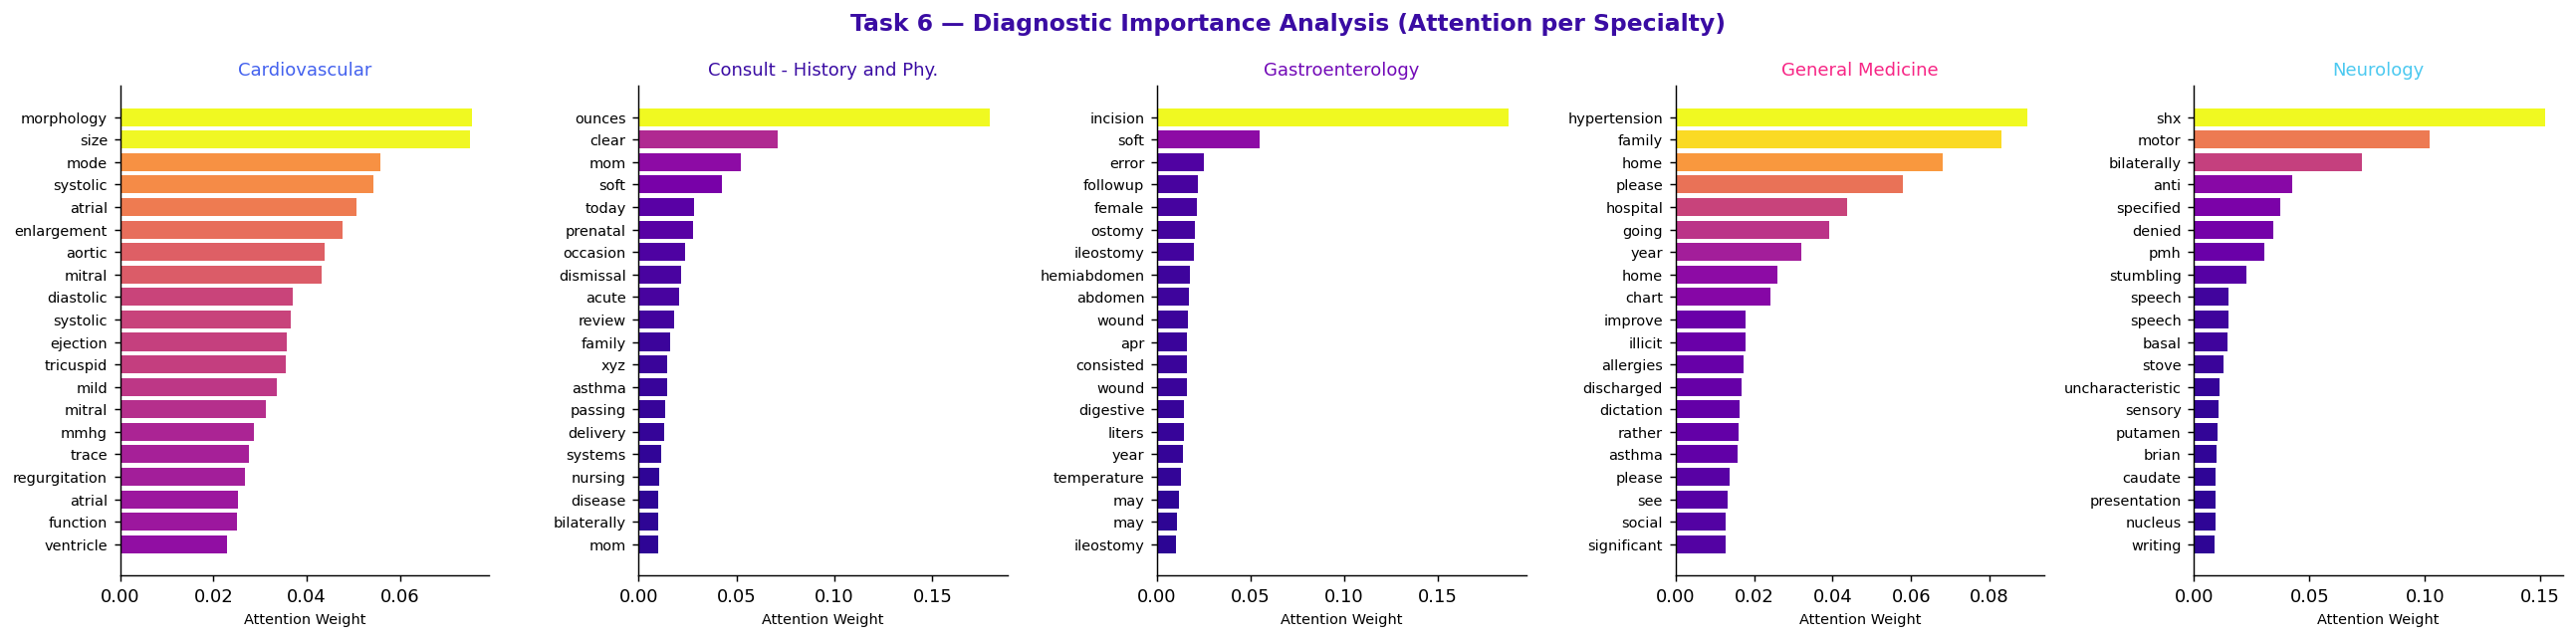


🔑 Top diagnostic terms per specialty (TF-IDF):
  Cardiovascular / Pulmonary              : artery, left, patient, coronary, right, chest, mg, normal
  Consult - History and Phy.              : history, patient, normal, pain, mg, past, denies, does
  Gastroenterology                        : patient, colon, procedure, scope, normal, gallbladder, stomach, esophagus
  General Medicine                        : history, patient, normal, mg, pain, negative, clear, daily
  Neurology                               : right, left, unremarkable, normal, patient, exam, brain, mri
  Orthopedic                              : patient, right, pain, knee, left, fracture, placed, tendon
  Radiology                               : normal, left, right, exam, unremarkable, images, ct, mild
  SOAP / Chart / Progress Notes           : mg, patient, today, pain, history, day, subjective, does
  Surgery                                 : patient, procedure, placed, left, right, anesthesia, using, incision
  Urol

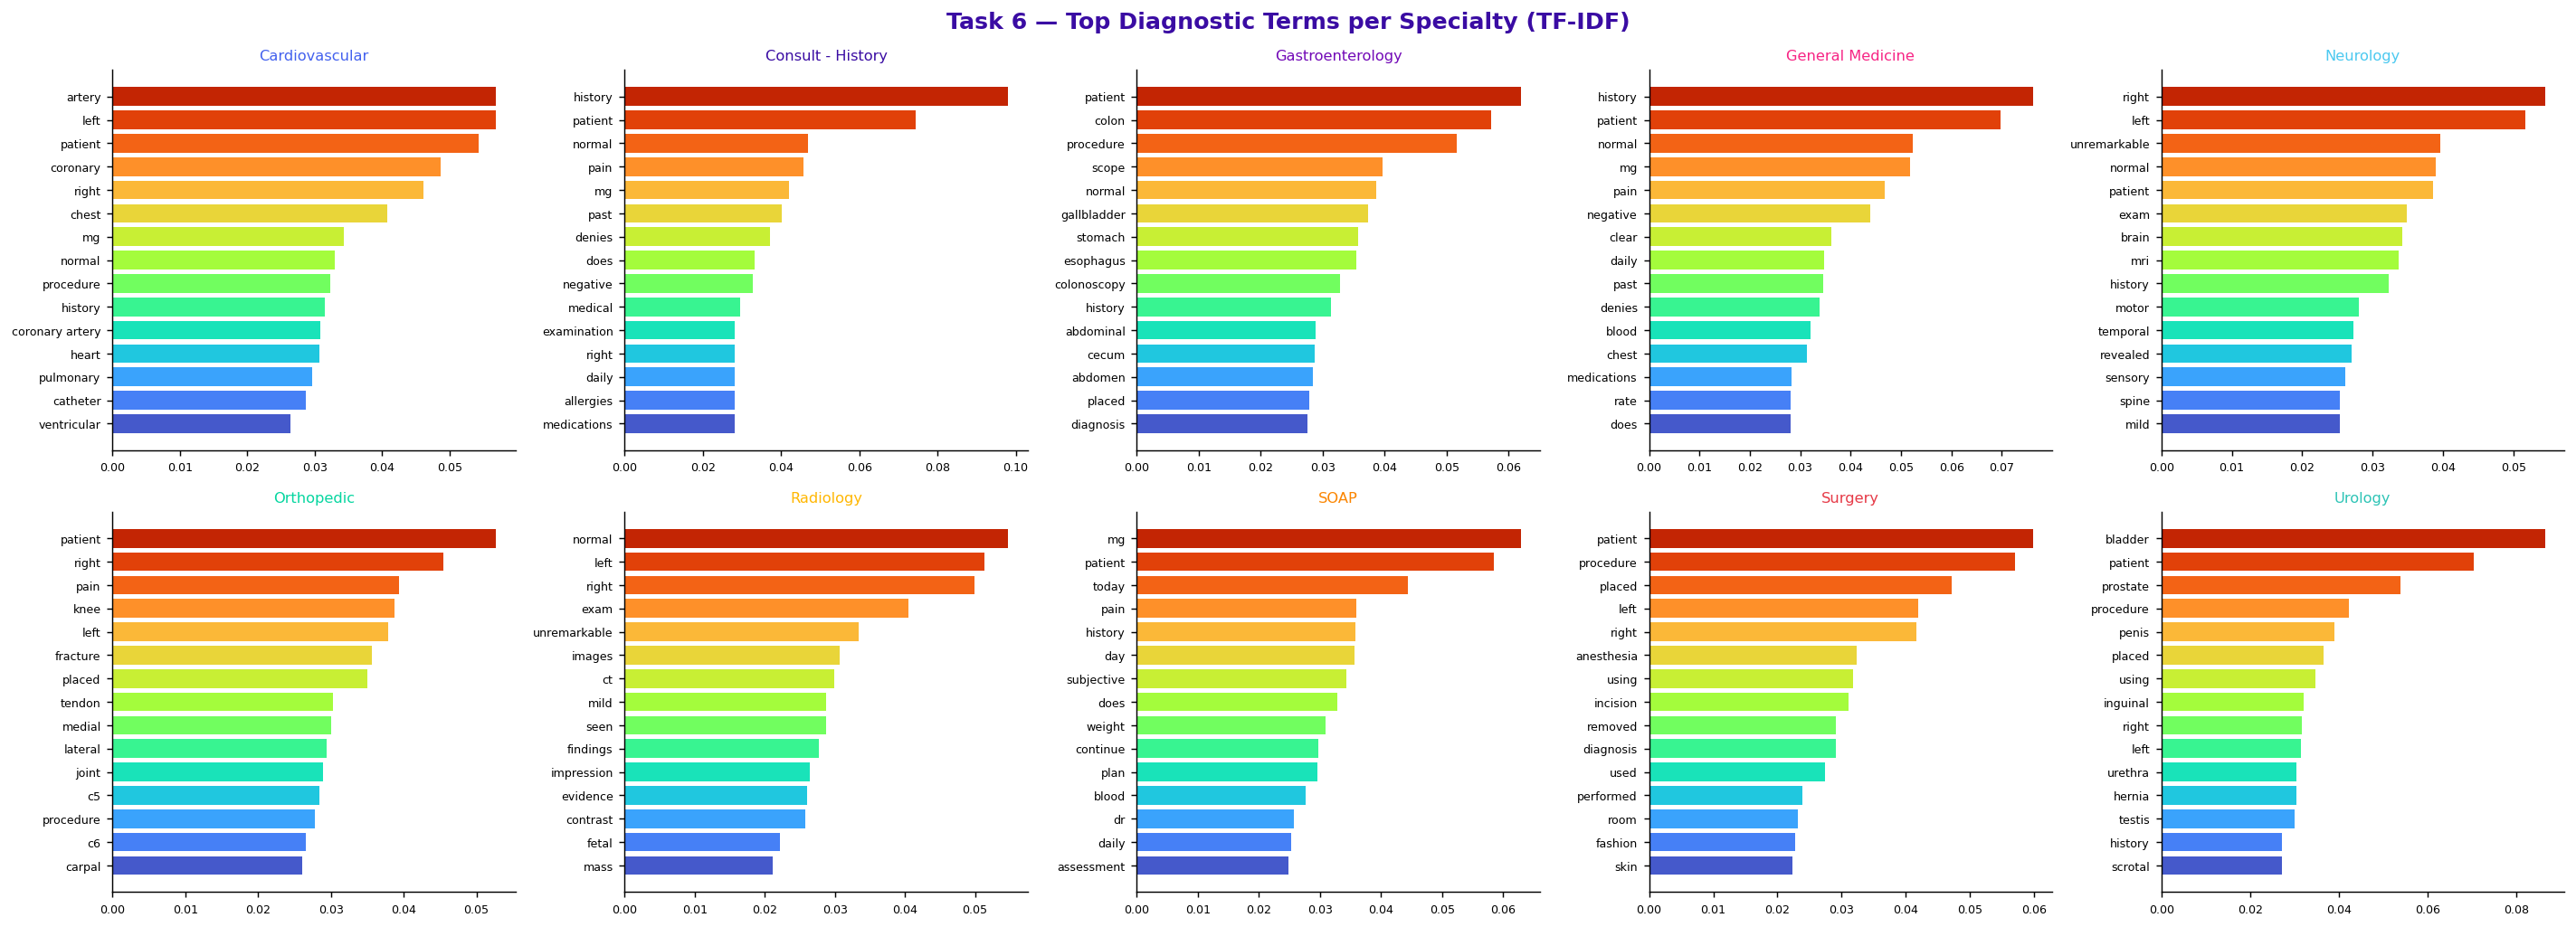

✅ Task 6 complete

  ALL 6 TASKS COMPLETE — see generated PNG/CSV/PT files
  📦 attn_model.pt                                  5762.9 KB
  📦 baseline_model.pt                              5271.2 KB
  📦 medical_vocabulary.csv                          353.8 KB
  📦 mtsamples.csv                                 16608.6 KB
  📦 task1_distribution.png                          145.7 KB
  📦 task1_lengths.png                                28.5 KB
  📦 task2_top50.png                                  81.6 KB
  📦 task2_wordcloud.png                             488.3 KB
  📦 task3_baseline_training.png                      67.8 KB
  📦 task3_confusion.png                             103.2 KB
  📦 task4_attn_training.png                          67.3 KB
  📦 task4_comparison.png                             23.5 KB
  📦 task5_pe_full.png                               318.5 KB
  📦 task5_pe_similarity.png                          40.5 KB
  📦 task6_attention_words.png                       112.1 KB
  📦 task6_

In [7]:
attn_model.eval()

# -- Collect attention weights for a small batch --
sample_texts, sample_labels = [], []
for spec in le.classes_[:5]:          # use first 5 specialties
    rows = df_cls[df_cls["medical_specialty"] == spec].head(4)
    sample_texts.extend(rows["transcription"].tolist())
    sample_labels.extend([spec] * len(rows))

def text_to_tensor(text, max_len=MAX_LEN):
    tokens = clean_text(text)
    ids    = encode(tokens, max_len)
    return torch.tensor([ids], dtype=torch.long).to(DEVICE), tokens[:max_len]

# -- Per-word attention scores for one example per specialty --
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Task 6 — Diagnostic Importance Analysis (Attention per Specialty)",
             fontsize=13, fontweight="bold", color="#3A0CA3")

for idx, spec in enumerate(le.classes_[:5]):
    row   = df_cls[df_cls["medical_specialty"] == spec].iloc[0]
    xten, tokens_used = text_to_tensor(row["transcription"])

    with torch.no_grad():
        _, attn_w = attn_model(xten, return_attn=True)   # (1, L, L)

    scores = attn_w[0, 0, :len(tokens_used)].cpu().numpy()  # CLS → all tokens
    top_k  = min(20, len(tokens_used))
    top_ids   = np.argsort(scores)[::-1][:top_k]
    top_words = [tokens_used[i] for i in top_ids]
    top_vals  = scores[top_ids]

    ax = axes[idx]
    cmap  = plt.cm.plasma
    cols  = cmap(top_vals / (top_vals.max() + 1e-9))
    ax.barh(range(top_k), top_vals[::-1], color=cols[::-1])
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(top_words[::-1], fontsize=8)
    ax.set_title(spec.split("/")[0].strip(), fontsize=10, color=PALETTE[idx])
    ax.set_xlabel("Attention Weight", fontsize=8)

plt.tight_layout()
plt.savefig("task6_attention_words.png", bbox_inches="tight")
plt.show()

# -- TF-IDF global diagnostic terms --
tfidf = TfidfVectorizer(max_features=5000, stop_words="english",
                        ngram_range=(1, 2))
tfidf.fit(df_cls["transcription"])
feature_names = np.array(tfidf.get_feature_names_out())

print("\n🔑 Top diagnostic terms per specialty (TF-IDF):")
fig_tfidf, axes = plt.subplots(2, 5, figsize=(22, 8))
fig_tfidf.suptitle("Task 6 — Top Diagnostic Terms per Specialty (TF-IDF)",
                   fontsize=14, fontweight="bold", color="#3A0CA3")

for ax_idx, spec in enumerate(le.classes_):
    sub   = df_cls[df_cls["medical_specialty"] == spec]["transcription"]
    tmat  = tfidf.transform(sub)
    means = np.asarray(tmat.mean(axis=0)).flatten()
    top20 = np.argsort(means)[::-1][:15]
    words = feature_names[top20]
    vals  = means[top20]
    print(f"  {spec:40s}: {', '.join(words[:8])}")

    ax = axes[ax_idx // 5, ax_idx % 5]
    ax.barh(range(15), vals[::-1],
            color=plt.cm.turbo(np.linspace(0.1, 0.9, 15)))
    ax.set_yticks(range(15))
    ax.set_yticklabels(words[::-1], fontsize=7)
    ax.set_title(spec.split("/")[0][:18].strip(), fontsize=9, color=PALETTE[ax_idx % 10])
    ax.tick_params(axis="x", labelsize=7)

plt.tight_layout()
plt.savefig("task6_tfidf_terms.png", bbox_inches="tight")
plt.show()
print("✅ Task 6 complete")

print("\n" + "="*65)
print("  ALL 6 TASKS COMPLETE — see generated PNG/CSV/PT files")
print("="*65)

# ── List all artifacts ──
for f in sorted(os.listdir(".")):
    if f.endswith((".png", ".csv", ".pt")):
        size = os.path.getsize(f)/1024
        print(f"  📦 {f:45s} {size:>7.1f} KB")